In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

In [4]:
EBC = pd.read_csv('equal_beta_portfolio_return.csv', index_col=0)
EBC.columns = ["EBC"]
EBC.index = pd.to_datetime(EBC.index)
EBC

,EBC
date,
1967-01-01,0.105809
1967-02-01,0.007303
1967-03-01,0.043577
1967-04-01,0.032736
1967-05-01,-0.027935
...,...
2024-08-01,0.030202
2024-09-01,0.016253
2024-10-01,-0.016896


In [5]:
ff_df = pd.read_csv("F-F_Research_Data_5_Factors_2x3.csv", index_col=0, skiprows=3)

# Keep only rows with YYYYMM format
ff_df = ff_df[ff_df.index.astype(str).str.match(r"^\d{6}$")]

# Convert index to period-end timestamps (e.g., '202401' -> '2024-01-31')
ff_df.index = pd.to_datetime(ff_df.index.astype(str), format="%Y%m").to_period("M").to_timestamp("M")

# Convert all factor values to numeric and scale to decimal
ff_df = ff_df.apply(pd.to_numeric, errors='coerce') / 100

ff_df.index = pd.to_datetime(ff_df.index).to_period('M').start_time

ff_df = ff_df.loc[EBC.index]

ff_df = ff_df["RF"]
ff_df

date
1967-01-01    0.0043
1967-02-01    0.0036
1967-03-01    0.0039
1967-04-01    0.0032
1967-05-01    0.0033
               ...  
2024-08-01    0.0048
2024-09-01    0.0040
2024-10-01    0.0039
2024-11-01    0.0040
2024-12-01    0.0037
Name: RF, Length: 696, dtype: float64

In [6]:
Cap_EBC = pd.read_csv('spread.csv', index_col=0)
Cap_EBC.index = pd.to_datetime(Cap_EBC.index)
Cap_EBC

,Spread Return
date,
1967-01-01,-0.022394
1967-02-01,0.002736
1967-03-01,0.000430
1967-04-01,0.014722
1967-05-01,-0.016680
...,...
2024-08-01,-0.002086
2024-09-01,0.009603
2024-10-01,0.012110


In [7]:
sp_500 = pd.read_csv('sp500_returns_with_tickers.csv', index_col=0)
sp_500.index = pd.to_datetime(sp_500.index).to_period('M').start_time
sp500 = sp_500.loc[Cap_EBC.index]
sp500

,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
date,,,,,,,,,,,,,,,,,,,,,
1967-01-01,0.140523,0.145374,0.146104,NaN,0.105364,NaN,NaN,NaN,-0.045045,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1967-02-01,-0.036103,-0.015385,-0.019830,NaN,0.029463,NaN,NaN,NaN,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1967-03-01,0.156627,0.020313,0.102339,NaN,0.112245,NaN,NaN,NaN,-0.035849,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1967-04-01,0.052083,0.007752,0.018568,NaN,0.039755,NaN,NaN,NaN,0.079208,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1967-05-01,-0.018812,-0.023077,-0.072917,NaN,-0.064706,NaN,NaN,NaN,-0.108257,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,NaN,NaN,NaN,NaN,NaN,0.013195,-0.001100,NaN,NaN,-0.071535,...,NaN,0.013319,0.042292,-0.310823,0.321675,NaN,0.005460,NaN,0.122718,-0.077391
2024-09-01,NaN,NaN,NaN,NaN,NaN,0.206030,0.031548,NaN,NaN,0.038948,...,NaN,0.062707,-0.016385,0.019284,0.010950,NaN,0.015013,NaN,-0.002580,0.221942
2024-10-01,NaN,NaN,NaN,NaN,NaN,-0.012676,-0.055659,NaN,NaN,0.008538,...,NaN,-0.015826,0.025228,-0.046589,0.014313,NaN,0.041981,NaN,0.042466,-0.045025


In [8]:
rf = ff_df.reindex(EBC.index)

EBC = EBC.subtract(rf, axis=0)
Cap_EBC = Cap_EBC.subtract(rf, axis=0)
sp500 = sp500.subtract(rf, axis=0)
EBC


,EBC
date,
1967-01-01,0.101509
1967-02-01,0.003703
1967-03-01,0.039677
1967-04-01,0.029536
1967-05-01,-0.031235
...,...
2024-08-01,0.025402
2024-09-01,0.012253
2024-10-01,-0.020796


<Axes: xlabel='date'>

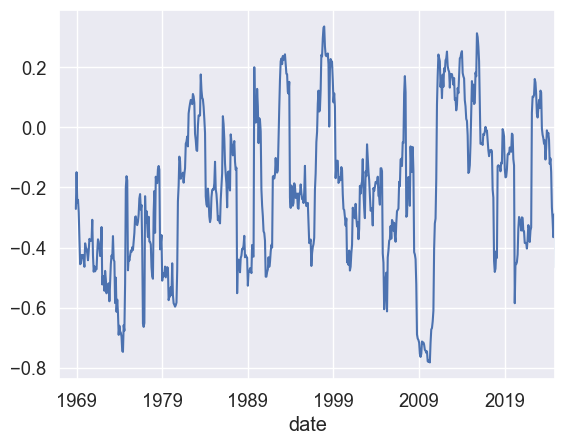

In [36]:
corr = EBC["EBC"].rolling(window=24).corr(Cap_EBC["Spread Return"])
corr.plot()

<Axes: xlabel='date'>

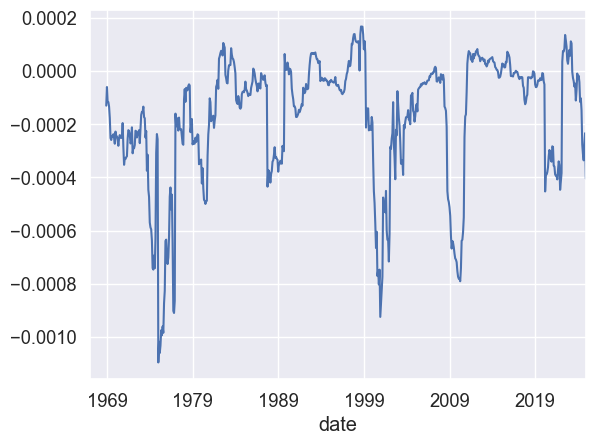

In [37]:
cov = EBC["EBC"].rolling(window=24).cov(Cap_EBC["Spread Return"])
cov.plot()

In [9]:
def compute_betas(sp500, factor_returns, ROLLING_WINDOW=36, MIN_OBS=10):
    """2 pass multi factor Fama-MacBeth"""

    asset_cols = sp500.columns
    combined = sp500.join(factor_returns, how="inner")

    # Prepare betas containers as float from the start
    betas_dict = {
        f: pd.DataFrame(index=pd.Index([], name="date"), columns=asset_cols, dtype=float)
        for f in factor_returns.columns
    }
    beta_dates = []

    # ---------- First pass: rolling time-series ----------
    for end_date in tqdm(combined.index[ROLLING_WINDOW-1:-1], desc="Time-series betas"):
        pos = combined.index.get_loc(end_date)
        next_date = combined.index[pos + 1]

        start_idx = pos - (ROLLING_WINDOW - 1)
        window_dates = combined.index[start_idx: start_idx + ROLLING_WINDOW]

        # Build window, drop any rows where either y or X has NaN
        x_win = factor_returns.loc[window_dates]
        for asset in asset_cols:
            y_win = sp500.loc[window_dates, asset]
            data = pd.concat([y_win, x_win], axis=1).dropna()
            if len(data) < MIN_OBS:
                for f in factor_returns.columns:
                    betas_dict[f].loc[next_date, asset] = np.nan
                continue

            Y = pd.to_numeric(data[asset], errors="coerce").astype(float)
            X = sm.add_constant(
                data[factor_returns.columns].apply(pd.to_numeric, errors="coerce").astype(float),
                has_constant="add"
            )

            # Guard against singular matrix if too few distinct X rows
            if X.shape[0] <= X.shape[1] or np.linalg.matrix_rank(X) < X.shape[1]:
                for f in factor_returns.columns:
                    betas_dict[f].loc[next_date, asset] = np.nan
                continue

            res = sm.OLS(Y, X).fit()

            for f in factor_returns.columns:
                betas_dict[f].loc[next_date, asset] = res.params.get(f, np.nan)

        beta_dates.append(next_date)

    return betas_dict

In [10]:
betas_EBC = compute_betas(sp500, EBC, 36, 10)
betas_Cap_EBC = compute_betas(sp500, Cap_EBC, 36, 10)

Time-series betas: 100%|██████████| 660/660 [10:41<00:00,  1.03it/s]


In [52]:
Betas_EBC = betas_EBC["EBC"]
# Betas_EBC = Betas_EBC[:400]
dic = {"EBC": Betas_EBC}
dic

{'EBC':                  ACF       ABK       AMT  JAVA        AN      ORCL      MSFT  \
 date                                                                           
 1970-01-01  1.333162  1.499542  0.510353   NaN  1.165416       NaN       NaN   
 1970-02-01  1.327381  1.527215  0.402780   NaN  1.034648       NaN       NaN   
 1970-03-01  1.290869  1.515709  0.349719   NaN  0.991152       NaN       NaN   
 1970-04-01  1.226908  1.561163  0.290040   NaN  0.949461       NaN       NaN   
 1970-05-01  1.165779  1.588972  0.309336   NaN  0.936422       NaN       NaN   
 ...              ...       ...       ...   ...       ...       ...       ...   
 2024-08-01       NaN       NaN       NaN   NaN       NaN  1.179202  0.779066   
 2024-09-01       NaN       NaN       NaN   NaN       NaN  1.173630  0.763392   
 2024-10-01       NaN       NaN       NaN   NaN       NaN  1.198837  0.740915   
 2024-11-01       NaN       NaN       NaN   NaN       NaN  1.182902  0.686763   
 2024-12-01       NaN

In [53]:
Betas_Cap_EBC = betas_Cap_EBC["Spread Return"]
# Betas_Cap_EBC = Betas_Cap_EBC[:400]
dic2 = {"Spread Return": Betas_Cap_EBC}

In [55]:
# Two-way sort -> equal-weight portfolios -> TS regressions -> Fama-MacBeth
# Assumes:
# - sp500 : DataFrame of asset returns (index dates), columns = tickers
# - betas_EBC: dict returned by compute_betas, e.g. {'EBC': DataFrame(dates x tickers)}
# - betas_Cap_EBC: dict returned by compute_betas for the second factor (spread)
# - factor series (EBC, Cap_EBC) are available as DataFrames EBC and Cap_EBC used earlier

# PARAMETERS
n_q1 = 3
n_q2 = 3
min_assets_per_cell = 3  #require at least this many assets to compute a portfolio return

# pick factor names (from your betas dicts)
f1_name = list(betas_EBC.keys())[0]
f2_name = list(betas_Cap_EBC.keys())[0]

# intersect dates where both beta matrices have rows and sp500 has returns
dates1 = dic[f1_name].index
dates2 = dic2[f2_name].index
dates_common = dates1.intersection(dates2).intersection(sp500.index)

# container for portfolio returns (equal-weighted)
port_ret_rows = []

print(f"Using factor names: f1={f1_name}, f2={f2_name}")
print(f"Number of rebalance dates: {len(dates_common)}")

for date in tqdm(sorted(dates_common), desc="forming portfolios"):
    try:
        beta1 = dic[f1_name].loc[date]   # Series indexed by asset
        beta2 = dic2[f2_name].loc[date]
    except KeyError:
        # skip if a factor missing for this date
        continue

    # returns at the same date (matching compute_betas design)
    if date not in sp500.index:
        continue
    ret_t = sp500.loc[date]

    df = pd.DataFrame({
        'beta1': beta1,
        'beta2': beta2,
        'ret': ret_t
    })

    df = df.dropna(subset=['beta1', 'beta2', 'ret'])
    if df.shape[0] == 0:
        continue

    # create quantiles robustly: try qcut, but fallback to rank-based if qcut fails
    def assign_q(series, nq):
        try:
            q = pd.qcut(series, nq, labels=False) + 1
        except Exception:
            # fallback: rank / quantiles
            ranks = series.rank(method='first')
            q = pd.cut(ranks, bins=nq, labels=False) + 1
        return nq + 1 - q

    df['q1'] = assign_q(df['beta1'], n_q1)
    print(df["q1"])
    df['q2'] = assign_q(df['beta2'], n_q2)

    # compute equal-weighted return for each cell
    for i in range(1, n_q1+1):
        for j in range(1, n_q2+1):
            cell = df[(df['q1'] == i) & (df['q2'] == j)]
            if cell.shape[0] < min_assets_per_cell:
                # not enough assets -> nan (keeps panel consistent)
                ret_ew = np.nan
                n_assets = cell.shape[0]
            else:
                ret_ew = cell['ret'].mean()
                n_assets = cell.shape[0]

            port_ret_rows.append({
                'date': date,
                'q1': i,
                'q2': j,
                'ret_ew': ret_ew,
                'n_assets': n_assets
            })

# build DataFrame of portfolio returns
portrets = pd.DataFrame(port_ret_rows)
portrets['date'] = pd.to_datetime(portrets['date'])
portrets = portrets.set_index(['date', 'q1', 'q2']).sort_index()

# Pivot to wide: columns are portfolio labels like "q1_q2" (useful for regressions)
portrets_wide = portrets['ret_ew'].unstack(level=[1,2])  # columns MultiIndex (q1,q2)
# flatten cols to strings
portrets_wide.columns = [f"Q{c[0]}_Q{c[1]}" for c in portrets_wide.columns]
portrets_wide = portrets_wide.sort_index(axis=1)

print("\nPortfolio panel shape (dates x portfolios):", portrets_wide.shape)
print("Example columns:", portrets_wide.columns[:8].tolist())
print(portrets_wide.head(100))

# ============================
# 1) Time-series regressions per portfolio (TS betas, alphas)
# ============================
# prepare factor returns series aligned to the portfolio index
# factor DataFrames EBC and Cap_EBC already exist in your workspace; ensure they align
factors = pd.concat([EBC, Cap_EBC], axis=1).dropna()
factors = factors.loc[portrets_wide.index.intersection(factors.index)]
portrets_wide = portrets_wide.loc[portrets_wide.index.intersection(factors.index)]

# ensure same date order
factors = factors.loc[portrets_wide.index]

ts_res = {}   # store regression results per portfolio
for port in portrets_wide.columns:
    y = portrets_wide[port].dropna()
    if len(y) < 12:
        # skip portfolios with too few observations
        ts_res[port] = None
        continue
    X = factors.loc[y.index]
    Xc = sm.add_constant(X, has_constant='add')
    try:
        model = sm.OLS(y, Xc).fit()
    except Exception as e:
        ts_res[port] = None
        continue

    ts_res[port] = {
        'alpha': model.params['const'],
        'alpha_t': model.tvalues['const'],
        'betaEBC': model.params.get(f1_name, np.nan),
        'betaCap_EBC': model.params.get(f2_name, np.nan),
        'betaEBC_t': model.tvalues.get(f1_name, np.nan),
        'betaCap_EBC_t': model.tvalues.get(f2_name, np.nan),
        'rsq': model.rsquared,
        'nobs': int(model.nobs)
    }

# TS results DataFrame
ts_summary = pd.DataFrame.from_dict(ts_res, orient='index')
print("\nTime-series regressions summary:")
print(ts_summary.dropna().head(25))

# ============================
# 2) Fama-MacBeth across portfolios
#    - Step A: get portfolio betas (we use the TS full-sample betas estimated above)
#    - Step B: for each date t, run cross-sectional regression: R_pt = gamma0_t + gamma1_t * beta1_p + gamma2_t * beta2_p + e_pt
#    - Step C: average gamma_t across time, compute t-stats
# ============================

# collect portfolio-level betas (from ts_summary)
beta_table = ts_summary[['betaEBC', 'betaCap_EBC']].copy()
beta_table = beta_table.dropna()
print("aaaaa")
print(beta_table.head(25))

# Align portfolio returns to the set of portfolios for which we have betas
valid_ports = beta_table.index.tolist()
R_panel = portrets_wide[valid_ports].copy()

# make sure index order consistent with factors
R_panel = R_panel.loc[factors.index.intersection(R_panel.index)]
print("aaaaa")
print(R_panel)
factors = factors.loc[R_panel.index]
print("aaaaa")
print(factors)

# At each date, run the cross-section
gamma_rows = []
cs_nobs = 0
for date, row in R_panel.iterrows():
    R_t = row.dropna()
    if R_t.shape[0] < 3:
        gamma_rows.append({'date': date, 'alpha': np.nan, 'lambdaEBC': np.nan, 'lambda_Cap_EBC': np.nan})
        continue

    # the betas are time-invariant here (portfolio-level)
    beta_mat = beta_table.loc[R_t.index]  # rows = portfolios in cross-section
    X_cs = sm.add_constant(beta_mat)
    try:
        res_cs = sm.OLS(R_t.values, X_cs.values).fit()
        params = res_cs.params
        gamma_rows.append({'date': date, 'alpha': params[0], 'lambdaEBC': params[1], 'lambda_Cap_EBC': params[2]})
        cs_nobs += 1
    except Exception:
        gamma_rows.append({'date': date, 'alpha': np.nan, 'lambdaEBC': np.nan, 'lambda_Cap_EBC': np.nan})

gammas = pd.DataFrame(gamma_rows).set_index('date')
print("aaaaa")
print(gammas)

# drop missing
gammas = gammas.dropna()

# FM estimates: mean of gamma_t and t-stat = mean(gamma)/ (std(gamma)/sqrt(T))
T_eff = gammas.shape[0]
fm_mean = gammas.mean()
fm_se = gammas.std(ddof=1) / np.sqrt(T_eff)
fm_tstats = fm_mean / fm_se

fm_table = pd.DataFrame({
    'lambda_mean': fm_mean,
    'lambda_se': fm_se,
    'lambda_fm_tstat': fm_tstats
})
print("\nFama-MacBeth results (factor premia):")
print(fm_table)

# ============================
# 3) Pricing errors (alphas) under FM prices
#    For each portfolio p: alpha_FM_p = mean(R_p) - (beta_p1 * gamma1_mean + beta_p2 * gamma2_mean + gamma0_mean)
#    Also present TS regression alpha for comparison
# ============================
gamma0_bar = fm_table.loc['alpha', 'lambda_mean']
gamma1_bar = fm_table.loc['lambdaEBC', 'lambda_mean']
gamma2_bar = fm_table.loc['lambda_Cap_EBC', 'lambda_mean']

portfolio_mean_returns = R_panel.mean()
pricing_errors = []
for p in valid_ports:
    mean_r = portfolio_mean_returns[p]
    b1 = beta_table.loc[p, 'betaEBC']
    b2 = beta_table.loc[p, 'betaCap_EBC']
    alpha_fm = mean_r - (gamma0_bar + gamma1_bar * b1 + gamma2_bar * b2)
    ts_alpha = ts_summary.loc[p, 'alpha'] if p in ts_summary.index else np.nan
    pricing_errors.append({
        'portfolio': p,
        'mean_return': mean_r,
        'betaEBC': b1,
        'betaCap_EBC': b2,
        'alpha_ts': ts_alpha,
        'alpha_fm': alpha_fm
    })

pricing_df = pd.DataFrame(pricing_errors).set_index('portfolio').sort_index()
print("\nPricing errors and betas for portfolios:")
print(pricing_df.head(25))

# ============================
# Niceties: show heatmaps / tables
# ============================
# reshape pricing_df into q1/q2 grid for alpha_fm and mean_return
grid_mean = pricing_df['mean_return'].copy()
grid_alpha = pricing_df['alpha_fm'].copy()

# helper to turn 'Q{a}_Q{b}' -> (a,b)
def split_label(lbl):
    parts = lbl.replace('Q','').split('_')
    return int(parts[0]), int(parts[1])

# build DataFrames
mean_grid = pd.DataFrame(np.nan, index=range(1, n_q1+1), columns=range(1, n_q2+1))
alpha_grid = mean_grid.copy()
for p in pricing_df.index:
    a,b = split_label(p)
    mean_grid.loc[a,b] = pricing_df.loc[p, 'mean_return']
    alpha_grid.loc[a,b] = pricing_df.loc[p, 'alpha_fm']

print("\nMean returns grid (rows = q1, cols = q2):")
print(mean_grid)
print("\nFM pricing error grid (alpha):")
print(alpha_grid)

# Save outputs for inspection if desired
# portrets_wide.to_csv('portfolios_returns_ew.csv')
# ts_summary.to_csv('portfolio_ts_summary.csv')
# fm_table.to_csv('fama_macbeth_results.csv')
# pricing_df.to_csv('portfolio_pricing_errors.csv')



Using factor names: f1=EBC, f2=Spread Return
Number of rebalance dates: 660


forming portfolios:   4%|▍         | 28/660 [00:00<00:02, 277.04it/s]

ACF     1
AMT     3
AN      2
AYE     3
HON     1
       ..
IBP     3
CLX     2
SFF     3
DFC     3
CFIP    1
Name: q1, Length: 492, dtype: int64
ACF     1
AMT     3
AN      2
AYE     3
HON     2
       ..
IBP     3
CLX     1
SFF     3
DFC     3
CFIP    2
Name: q1, Length: 492, dtype: int64
ACF     1
AMT     3
AN      2
AYE     3
HON     2
       ..
IBP     3
CLX     1
SFF     3
DFC     2
CFIP    2
Name: q1, Length: 490, dtype: int64
ACF     1
AMT     3
AN      2
AYE     3
HON     2
       ..
IBP     3
CLX     1
SFF     3
DFC     2
CFIP    2
Name: q1, Length: 478, dtype: int64
ACF     2
AMT     3
AN      2
AYE     3
HON     2
       ..
IBP     3
CLX     1
SFF     3
DFC     1
CFIP    2
Name: q1, Length: 479, dtype: int64
ACF     1
AMT     3
AN      3
AYE     3
HON     2
       ..
CLX     1
SFF     3
DFC     1
UNP     2
CFIP    2
Name: q1, Length: 477, dtype: int64
ACF     2
AMT     3
AN      2
AYE     3
HON     2
       ..
CLX     1
SFF     3
DFC     1
UNP     1
CFIP    2
Name: q1, Leng

forming portfolios:  10%|█         | 66/660 [00:00<00:01, 334.91it/s]

ACF    2
AMT    2
AYE    2
HON    3
AMX    3
      ..
MML    1
AHM    1
HT     2
GHB    3
NWP    3
Name: q1, Length: 487, dtype: int64


...

forming portfolios:  89%|████████▉ | 589/660 [00:01<00:00, 354.79it/s]

ORCL    2
MSFT    3
TROW    2
HON     2
EMC     1
       ..
MJN     3
CFN     2
DG.2    1
VAL     3
QEP     1
Name: q1, Length: 484, dtype: int64
ORCL    2
MSFT    3
TROW    2
HON     2
EMC     1
       ..
MJN     3
CFN     3
DG.2    1
VAL     2
QEP     1
Name: q1, Length: 484, dtype: int64
ORCL    2
MSFT    3
TROW    2
HON     2
EMC     2
       ..
MJN     3
CFN     2
DG.2    1
VAL     2
QEP     1
Name: q1, Length: 483, dtype: int64
ORCL    1
MSFT    3
TROW    2
HON     2
EMC     1
       ..
MJN     3
CFN     2
DG.2    1
VAL     2
QEP     1
Name: q1, Length: 487, dtype: int64
ORCL    1
MSFT    3
TROW    1
HON     2
EMC     2
       ..
MJN     2
CFN     2
DG.2    1
VAL     2
QEP     1
Name: q1, Length: 488, dtype: int64
ORCL    1
MSFT    3
TROW    1
HON     2
EMC     2
       ..
MJN     2
CFN     2
DG.2    1
VAL     2
QEP     1
Name: q1, Length: 487, dtype: int64
ORCL    2
MSFT    3
TROW    1
HON     2
EMC     2
       ..
MJN     2
CFN     2
DG.2    1
VAL     2
QEP     1
Name: q1, Leng

forming portfolios: 100%|██████████| 660/660 [00:01<00:00, 364.73it/s]

ORCL    2
MSFT    2
TROW    2
HON     2
ADM     2
       ..
AVGO    3
VRSK    3
DG.2    3
FTNT    1
CBOE    3
Name: q1, Length: 488, dtype: int64
ORCL    2
MSFT    2
TROW    2
HON     2
ADM     2
       ..
AVGO    3
VRSK    3
DG.2    3
FTNT    1
CBOE    3
Name: q1, Length: 488, dtype: int64
ORCL    3
MSFT    3
TROW    2
HON     2
ADM     2
       ..
AVGO    3
VRSK    3
DG.2    3
FTNT    2
CBOE    3
Name: q1, Length: 486, dtype: int64
ORCL    3
MSFT    3
TROW    2
HON     2
ADM     2
       ..
AVGO    3
VRSK    3
DG.2    3
FTNT    3
CBOE    3
Name: q1, Length: 487, dtype: int64
ORCL    3
MSFT    3
TROW    2
HON     2
ADM     2
       ..
AVGO    2
VRSK    3
DG.2    3
FTNT    2
CBOE    3
Name: q1, Length: 486, dtype: int64
ORCL    3
MSFT    3
TROW    2
HON     2
ADM     2
       ..
AVGO    2
VRSK    3
DG.2    3
FTNT    2
CBOE    3
Name: q1, Length: 488, dtype: int64
ORCL    3
MSFT    3
TROW    2
HON     2
ADM     2
       ..
AVGO    3
VRSK    3
DG.2    3
FTNT    2
CBOE    3
Name: q1, Leng


Time-series regressions summary:
          alpha   alpha_t   betaEBC  betaCap_EBC   betaEBC_t  betaCap_EBC_t  \
Q1_Q1 -0.004058 -3.145428  1.395164     1.080212   48.132459      13.666529   
Q1_Q2 -0.001958 -2.349506  1.304221     0.099912   69.998466       1.971896   
Q1_Q3 -0.000293 -0.275730  1.408392    -0.311405   59.327575      -4.823772   
Q2_Q1 -0.001940 -2.773839  1.146179     0.893834   73.331793      21.029298   
Q2_Q2 -0.000590 -1.270311  1.059034    -0.043456  102.074996      -1.540229   
Q2_Q3  0.000122  0.178545  1.114072    -0.399102   72.929926      -9.607379   
Q3_Q1 -0.000777 -1.131676  0.928622     0.813105   60.537909      19.492313   
Q3_Q2  0.001109  2.019434  0.808823    -0.189625   65.887555      -5.680337   
Q3_Q3  0.001370  1.385737  0.859928    -0.425462   38.616754      -7.134593   

            rsq  nobs  
Q1_Q1  0.783503   645  
Q1_Q2  0.886220   660  
Q1_Q3  0.855433   660  
Q2_Q1  0.891422   660  
Q2_Q2  0.944108   660  
Q2_Q3  0.902294   660  
Q3_Q1  

Text(163.25, 0.5, 'ECB quantile')

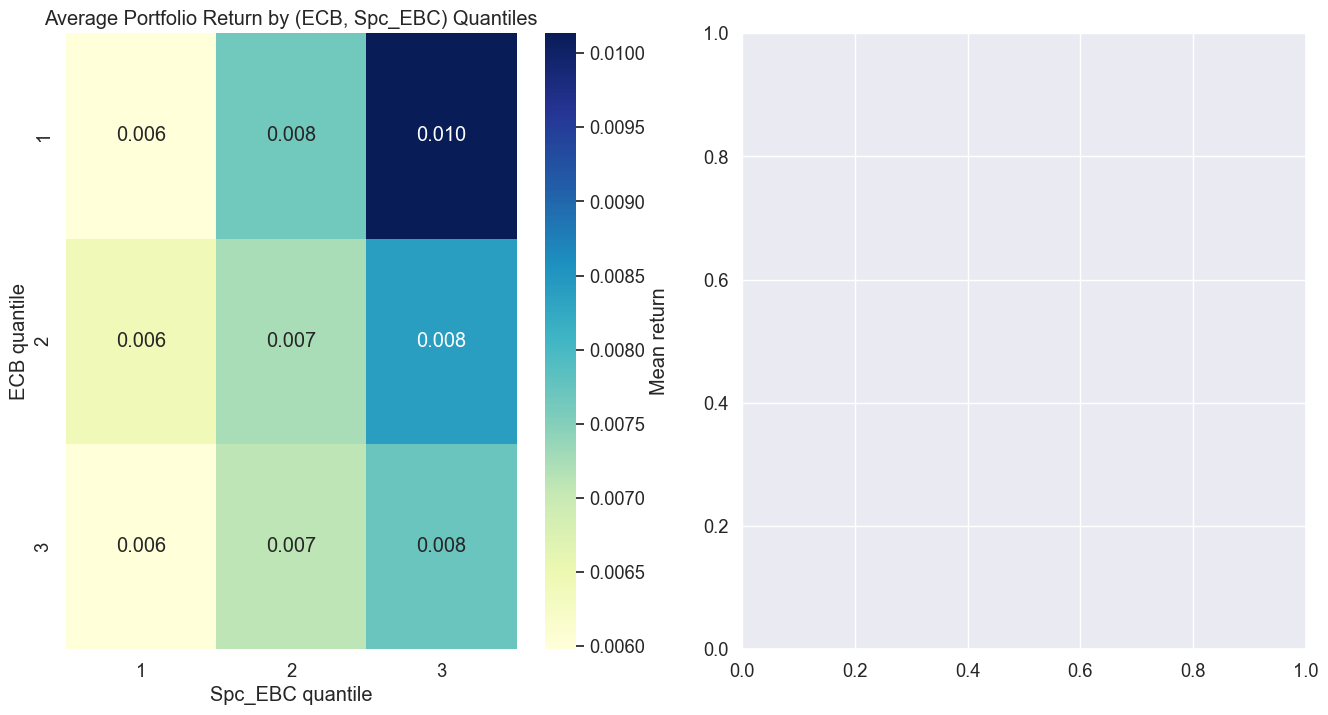

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# set up figure aesthetics
plt.style.use("seaborn-v0_8-whitegrid")
sns.set(font_scale=1.2)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# heatmap 1: mean returns
sns.heatmap(
    mean_grid.astype(float),
    ax=axes[0],
    cmap="YlGnBu",
    annot=True,
    fmt=".3f",
    cbar_kws={'label': 'Mean return'}
)
axes[0].set_title("Average Portfolio Return by (ECB, Spc_EBC) Quantiles")
axes[0].set_xlabel("Spc_EBC quantile")
axes[0].set_ylabel("ECB quantile")

# # heatmap 2: FM alpha (pricing errors)
# sns.heatmap(
#     alpha_grid.astype(float),
#     ax=axes[1],
#     cmap="RdBu_r",
#     center=0,
#     annot=True,
#     fmt=".3f",
#     cbar_kws={'label': 'Fama–MacBeth α'}
# )
# axes[1].set_title("Average FM Pricing Errors (Alphas)")
# axes[1].set_xlabel("Spc_EBC quantile")
# axes[1].set_ylabel("ECB quantile")

# plt.tight_layout()
# plt.show()


[Text(0, 0.5, 'High'), Text(0, 1.5, 'Middle'), Text(0, 2.5, 'Low')]

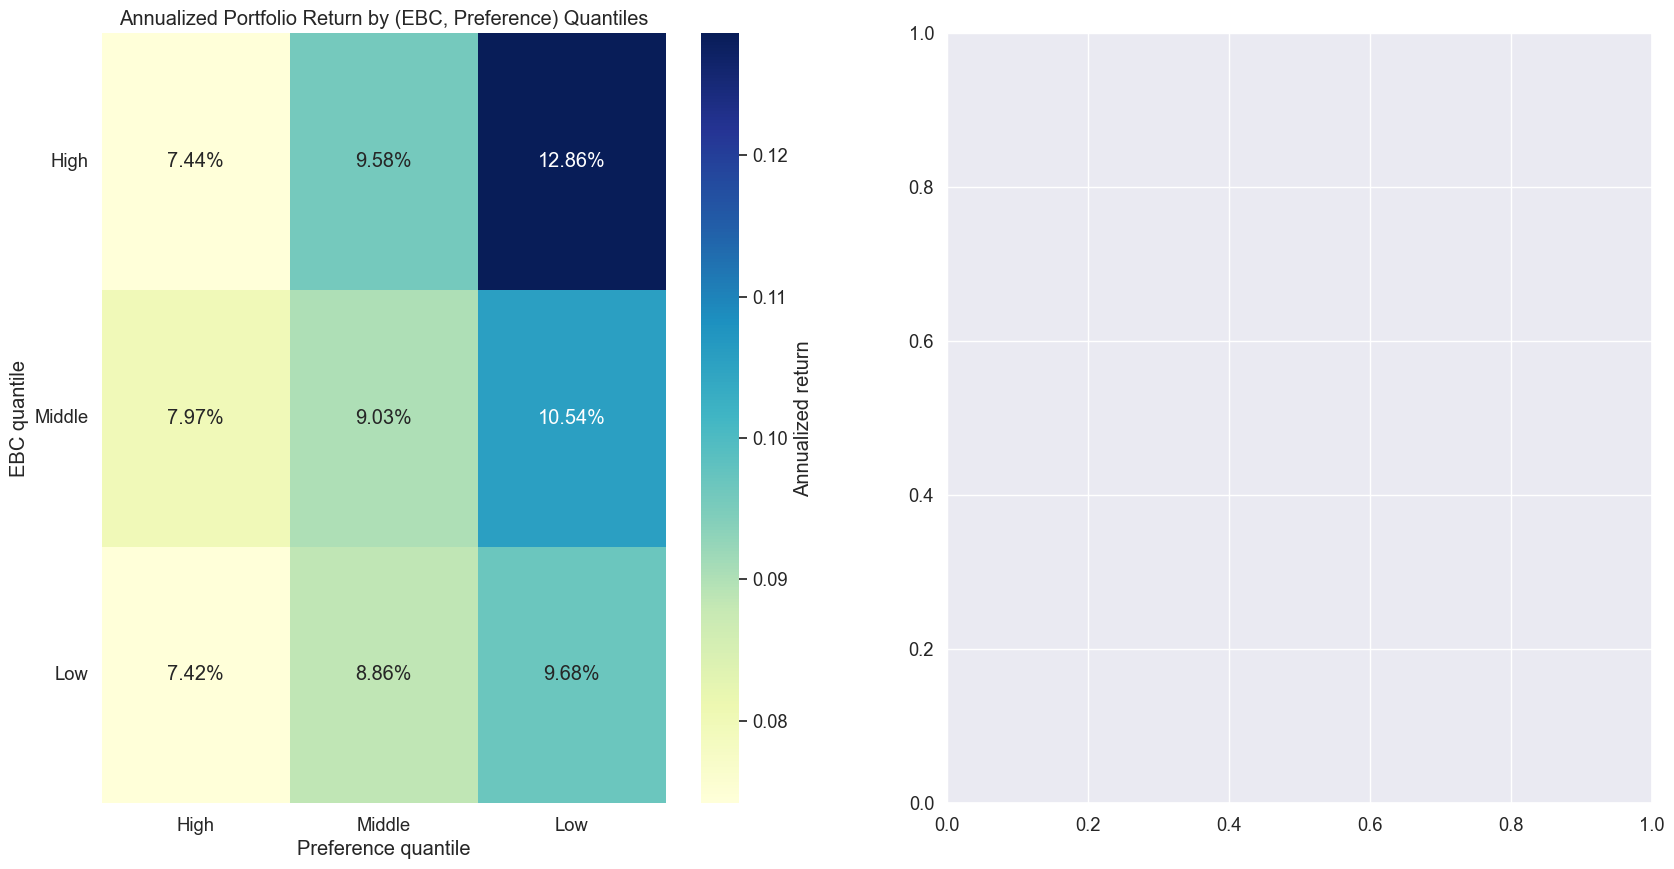

In [60]:
# annualize the grids
mean_grid_annual = (1 + mean_grid.astype(float))**12 - 1
alpha_grid_annual = (1 + alpha_grid.astype(float))**12 - 1

# plot heatmaps
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

labels = ['High', 'Middle', 'Low']

# heatmap 1: mean returns annualized
sns.heatmap(
    mean_grid_annual,
    ax=axes[0],
    cmap="YlGnBu",
    annot=True,
    fmt=".2%",
    cbar_kws={'label': 'Annualized return'}
)
axes[0].set_title("Annualized Portfolio Return by (EBC, Preference) Quantiles")
axes[0].set_xlabel("Preference quantile")
axes[0].set_ylabel("EBC quantile")
axes[0].set_xticklabels(labels)
axes[0].set_yticklabels(labels, rotation=0)


# # heatmap 2: FM alpha annualized
# sns.heatmap(
#     alpha_grid_annual,
#     ax=axes[1],
#     cmap="RdBu_r",
#     center=0,
#     annot=True,
#     fmt=".2%",
#     cbar_kws={'label': 'Annualized Fama–MacBeth α'}
# )
# axes[1].set_title("Annualized FM Pricing Errors (Alphas)")
# axes[1].set_xlabel("Preference quantile")
# axes[1].set_ylabel("EBC quantile")
# axes[1].set_xticklabels(labels)
# axes[1].set_yticklabels(labels, rotation=0)

# plt.tight_layout()
# plt.show()


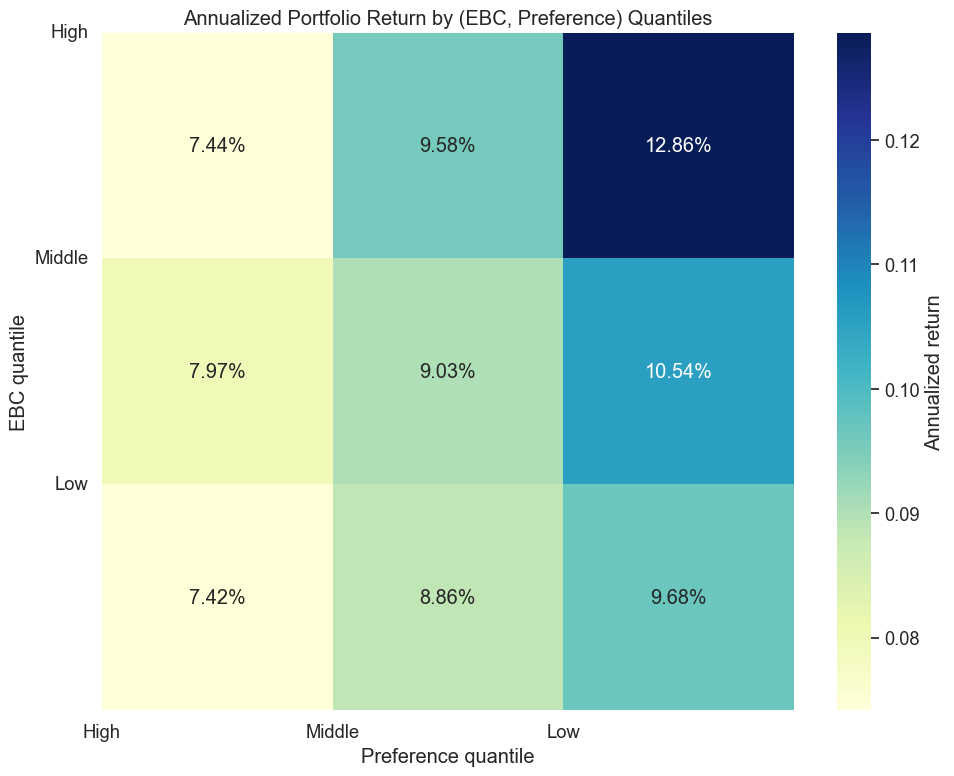

In [61]:
# annualize the mean grid
mean_grid_annual = (1 + mean_grid.astype(float))**12 - 1

# plot heatmap for annualized portfolio returns
plt.figure(figsize=(10, 8))

labels = ['High', 'Middle', 'Low']

sns.heatmap(
    mean_grid_annual,
    cmap="YlGnBu",
    annot=True,
    fmt=".2%",
    cbar_kws={'label': 'Annualized return'}
)
plt.title("Annualized Portfolio Return by (EBC, Preference) Quantiles")
plt.xlabel("Preference quantile")
plt.ylabel("EBC quantile")
plt.xticks(ticks=[0, 1, 2], labels=labels)
plt.yticks(ticks=[0, 1, 2], labels=labels, rotation=0)

plt.tight_layout()
plt.show()
